In [253]:
#Bibliotecas
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import re
import math

In [254]:
caminho_arquivo = "tratados_3det/nitrogen/nitrogen3.16E15"

def processar_arquivo(nome_arquivo):
    # Listas para armazenar as detecções por tipo de partícula e por detector
    positrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    electrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    muons_plus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    muons_minus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Listas para totais por detector
    total_por_detector = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Listas para somas de elétrons+pósitrons e múons+/-
    soma_electrons_positrons = {"TRIG1": [], "TRIG2": [], "TRIG3": []}
    soma_muons_plus_minus = {"TRIG1": [], "TRIG2": [], "TRIG3": []}

    # Abrir e ler o arquivo
    with open(nome_arquivo, 'r') as arquivo:
        for linha in arquivo:
            linha = linha.strip()

            # Processar apenas linhas que começam com TRIG
            if linha.startswith("TRIG"):
                partes = linha.split()
                detector = partes[0]  # TRIG1, TRIG2, TRIG3

                # Valores das partículas
                pos = int(partes[1])  # Pósitrons
                ele = int(partes[2])  # Elétrons
                mu_p = int(partes[3])  # Múons+
                mu_m = int(partes[4])  # Múons-

                # Adicionar os valores às listas correspondentes
                positrons[detector].append(pos)
                electrons[detector].append(ele)
                muons_plus[detector].append(mu_p)
                muons_minus[detector].append(mu_m)

                # Calcular totais
                total = pos + ele + mu_p + mu_m
                total_por_detector[detector].append(total)

                # Calcular somas
                soma_electrons_positrons[detector].append(pos + ele)
                soma_muons_plus_minus[detector].append(mu_p + mu_m)

    # Retornar os dados processados
    return {
        "positrons": positrons,
        "electrons": electrons,
        "muons_plus": muons_plus,
        "muons_minus": muons_minus,
        "total_por_detector": total_por_detector,
        "soma_electrons_positrons": soma_electrons_positrons,
        "soma_muons_plus_minus": soma_muons_plus_minus
    }

# Função principal
def main():
    
    dados = processar_arquivo(caminho_arquivo)

    # Alguns testes
    print("Detecções de pósitrons no TRIG1:", dados["positrons"]["TRIG1"])
    print("Total de partículas no TRIG2:", dados["total_por_detector"]["TRIG2"])
    print("Soma de elétrons e pósitrons no TRIG3:", dados["soma_electrons_positrons"]["TRIG3"])

    return dados



# Executar o programa
if __name__ == "__main__":
    dados_processados = main()


Detecções de pósitrons no TRIG1: [2, 26, 122, 28, 0, 79, 5, 19, 1, 31, 64, 6, 1, 36, 26, 3, 51, 32, 10, 0, 3, 6, 11, 0, 19, 1, 37, 56, 2, 29, 102, 24, 22, 65, 60, 0, 47, 0, 1, 11, 1, 1, 0, 3, 17, 12, 47, 37, 6, 0, 16, 18, 22, 2, 11, 0, 37, 10, 3, 18, 54, 0, 1, 1, 23, 28, 1, 20, 262, 9, 60, 2, 0, 78, 12, 186, 0, 1, 0, 7, 0, 12, 35, 0, 1, 0, 19, 31, 0, 15, 27, 5, 0, 15, 59, 26, 21, 36, 46, 21, 0, 47, 3, 1, 0]
Total de partículas no TRIG2: [7, 102, 254, 42, 0, 204, 16, 55, 1, 92, 128, 28, 1, 62, 79, 3, 127, 90, 26, 5, 6, 9, 15, 0, 49, 1, 60, 156, 2, 104, 257, 56, 71, 163, 161, 2, 69, 0, 2, 18, 4, 2, 1, 19, 41, 34, 158, 71, 20, 1, 31, 43, 57, 1, 31, 12, 83, 51, 21, 34, 151, 3, 14, 0, 49, 49, 1, 62, 632, 16, 133, 9, 1, 118, 13, 395, 0, 3, 0, 19, 10, 32, 70, 0, 0, 1, 88, 71, 0, 48, 41, 16, 0, 32, 146, 61, 41, 95, 84, 34, 0, 102, 10, 0, 1]
Soma de elétrons e pósitrons no TRIG3: [1, 77, 238, 29, 0, 152, 27, 50, 0, 101, 124, 6, 2, 73, 82, 1, 130, 79, 28, 0, 2, 11, 7, 0, 34, 8, 91, 127, 2, 78, 2

In [255]:
def formatar_string(s):

    nome_arquivo = s.split('/')[-1]
   
    match = re.match(r'([a-zA-Z]+)([0-9]+(?:\.[0-9]+)?[Ee][0-9]+)', nome_arquivo)

    if match:
        
        palavra = match.group(1).capitalize()
        numero = match.group(2)

        return f'{palavra} {numero}'
    else:
        return nome_arquivo

name = formatar_string(caminho_arquivo)
name

'Nitrogen 3.16E15'

In [256]:
# Posição dos tanques
x1 = [0, 800/np.sqrt(3)]
x2 = [-400, -400/np.sqrt(3)]
x3 = [400, -400/np.sqrt(3)]

# Distância dos tanques em relação ao centro
r1 = (x1[0]**2+x1[1]**2)**0.5
r2 = (x2[0]**2+x2[1]**2)**0.5
r3 = (x3[0]**2+x3[1]**2)**0.5


# Total de partículas em cada tanque
trig1_total = dados_processados['total_por_detector']['TRIG1']
trig2_total = dados_processados['total_por_detector']['TRIG2']
trig3_total = dados_processados['total_por_detector']['TRIG3']

print(trig1_total,'\n',
      trig2_total,'\n',
      trig3_total)

[3, 86, 300, 58, 0, 188, 18, 49, 1, 90, 143, 11, 3, 70, 77, 10, 128, 89, 28, 0, 6, 16, 24, 0, 43, 2, 88, 115, 4, 72, 263, 66, 61, 164, 148, 0, 103, 0, 2, 29, 2, 1, 1, 6, 50, 32, 114, 81, 13, 0, 38, 44, 57, 4, 23, 2, 94, 33, 6, 41, 146, 1, 6, 4, 51, 64, 1, 42, 643, 23, 139, 3, 1, 168, 33, 471, 1, 4, 0, 16, 5, 32, 95, 0, 3, 0, 45, 61, 0, 31, 76, 26, 1, 36, 158, 69, 45, 82, 109, 41, 0, 97, 13, 1, 3] 
 [7, 102, 254, 42, 0, 204, 16, 55, 1, 92, 128, 28, 1, 62, 79, 3, 127, 90, 26, 5, 6, 9, 15, 0, 49, 1, 60, 156, 2, 104, 257, 56, 71, 163, 161, 2, 69, 0, 2, 18, 4, 2, 1, 19, 41, 34, 158, 71, 20, 1, 31, 43, 57, 1, 31, 12, 83, 51, 21, 34, 151, 3, 14, 0, 49, 49, 1, 62, 632, 16, 133, 9, 1, 118, 13, 395, 0, 3, 0, 19, 10, 32, 70, 0, 0, 1, 88, 71, 0, 48, 41, 16, 0, 32, 146, 61, 41, 95, 84, 34, 0, 102, 10, 0, 1] 
 [2, 80, 239, 29, 1, 153, 27, 51, 1, 102, 124, 7, 4, 74, 83, 1, 131, 81, 28, 0, 3, 12, 7, 1, 34, 8, 92, 129, 2, 78, 289, 73, 77, 152, 161, 0, 92, 0, 0, 26, 1, 1, 1, 12, 41, 45, 110, 75, 12, 0, 

In [257]:
# Triangulação

triangulacao = [
    (a, b, c) for a, b, c in zip(trig1_total, trig2_total, trig3_total) if a != 0 and b != 0 and c != 0
]

trig1, trig2, trig3 = zip(*triangulacao) if triangulacao else ([], [], [])


print(trig1,'\n',
      trig2,'\n',
      trig3)

(3, 86, 300, 58, 188, 18, 49, 1, 90, 143, 11, 3, 70, 77, 10, 128, 89, 28, 6, 16, 24, 43, 2, 88, 115, 4, 72, 263, 66, 61, 164, 148, 103, 29, 2, 1, 1, 6, 50, 32, 114, 81, 13, 38, 44, 57, 4, 23, 2, 94, 33, 6, 41, 146, 1, 6, 51, 64, 42, 643, 23, 139, 3, 168, 33, 471, 4, 16, 5, 32, 95, 45, 61, 31, 76, 26, 36, 158, 69, 45, 82, 109, 41, 97, 13, 3) 
 (7, 102, 254, 42, 204, 16, 55, 1, 92, 128, 28, 1, 62, 79, 3, 127, 90, 26, 6, 9, 15, 49, 1, 60, 156, 2, 104, 257, 56, 71, 163, 161, 69, 18, 4, 2, 1, 19, 41, 34, 158, 71, 20, 31, 43, 57, 1, 31, 12, 83, 51, 21, 34, 151, 3, 14, 49, 49, 62, 632, 16, 133, 9, 118, 13, 395, 3, 19, 10, 32, 70, 88, 71, 48, 41, 16, 32, 146, 61, 41, 95, 84, 34, 102, 10, 1) 
 (2, 80, 239, 29, 153, 27, 51, 1, 102, 124, 7, 4, 74, 83, 1, 131, 81, 28, 3, 12, 7, 34, 8, 92, 129, 2, 78, 289, 73, 77, 152, 161, 92, 26, 1, 1, 1, 12, 41, 45, 110, 75, 12, 44, 40, 46, 8, 29, 10, 67, 44, 3, 74, 159, 1, 11, 45, 72, 25, 634, 15, 130, 5, 140, 11, 403, 3, 7, 3, 33, 82, 55, 82, 33, 57, 17, 41, 1

In [258]:
x_b = []
y_b = []

for i in range(len(trig1)):
        numerator = (trig1[i]*x1[0]+trig2[i]*x2[0]+trig3[i]*x3[0])
        demoninator = (trig1[i]+trig2[i]+trig3[i])
        numerator1 = (trig1[i]*x1[1]+trig2[i]*x2[1]+trig3[i]*x3[1])

        if demoninator == 0:
                x_b.append(0)
                y_b.append(0)
        else:
                x_b.append(numerator/demoninator)
                y_b.append(numerator1/demoninator)


In [259]:
data = {
    'x_b':x_b,
    'y_b':y_b,
    'trig1':trig1,
    'trig2':trig2,
    'trig3':trig3
}

df = pl.DataFrame(data, strict=False)

df = df.with_columns(
    [
        ((df['x_b']**2+df['y_b']**2)**0.5).alias('r_b'),
        (pl.col('trig1')/(math.pi*65**2)).alias('rho1'),
        (pl.col('trig2')/(math.pi*65**2)).alias('rho2'),
        (pl.col('trig3')/(math.pi*65**2)).alias('rho3')
    ]
)

df = df.with_columns(
    [
        (((x1[0]-df['x_b'])**2 + (x1[1]-df['y_b'])**2)**0.5).alias('r1_b'),
        (((x2[0]-df['x_b'])**2 + (x2[1]-df['y_b'])**2)**0.5).alias('r2_b'),
        (((x3[0]-df['x_b'])**2 + (x3[1]-df['y_b'])**2)**0.5).alias('r3_b'),
    ]
)

df

x_b,y_b,trig1,trig2,trig3,r_b,rho1,rho2,rho3,r1_b,r2_b,r3_b
f64,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64
-166.666667,-57.735027,3,7,2,176.383421,0.000226,0.000527,0.000151,545.690185,290.593263,592.546294
-32.835821,-8.617168,86,102,80,33.947706,0.006479,0.007685,0.006027,471.641791,429.228405,486.594633
-7.566204,31.160897,300,254,239,32.066321,0.022602,0.019136,0.018006,430.785769,471.912302,484.569033
-40.310078,80.560503,58,42,29,90.082723,0.00437,0.003164,0.002185,383.444423,475.825042,539.356649
-37.431193,8.051123,188,204,153,38.287266,0.014164,0.015369,0.011527,455.370112,434.249869,498.460487
…,…,…,…,…,…,…,…,…,…,…,…
-1.449275,42.673716,109,84,83,42.698318,0.008212,0.006329,0.006253,419.209005,483.43273,485.825118
30.508475,9.785598,41,34,43,32.039428,0.003089,0.002562,0.00324,453.122842,493.240724,440.990763
-15.172414,0.796345,97,102,91,15.193298,0.007308,0.007685,0.006856,461.333434,449.214932,475.468103


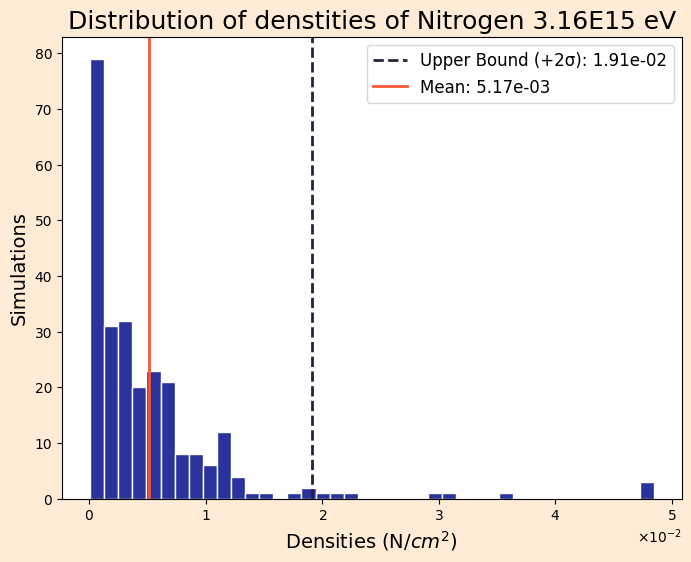

In [260]:
from matplotlib.ticker import ScalarFormatter

values = df.select(['rho1', 'rho2', 'rho3']).to_numpy().flatten()

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#FFEBD6')
plt.hist(values, color='#29339B', bins=40, edgecolor='white')
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0), useMathText=True)


plt.ylabel('Simulations')
plt.xlabel('Densities (N/$cm^2$)')  
plt.title('Distribution of denstities of ' + str(name) + ' eV', size=18)  

# Calcula a média e o desvio padrão dos dados
mean = values.mean()
std = values.std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2e}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2e}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Densities (N/$cm^2$)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/densities_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

In [261]:
#def calcular_s(rho_i, rho_j, r_i, r_j):
#    log_rho_diff = pl.col(rho_i).log() - pl.col(rho_j).log()
#    log_r_diff = pl.col(r_i).abs().log() - pl.col(r_j).abs().log()
#
#    s_expr = pl.when((log_rho_diff == 0) & (log_r_diff == 0)) \
#              .then(0) \
#              .otherwise(-log_rho_diff / log_r_diff)
#    
#    return s_expr
#
#df = df.with_columns([
#    calcular_s("rho1", "rho2", "r1_b", "r2_b").alias("s1"),
#    calcular_s("rho2", "rho3", "r2_b", "r3_b").alias("s2"),
#    calcular_s("rho1", "rho3", "r1_b", "r3_b").alias("s3"),
#])
#
#df = df.with_columns(
#    df.select(["s1", "s2", "s3"]).mean_horizontal().alias("s_mean")
#)
#df

In [262]:
#r0 = 7800
#
## Função para o ajuste
#def model(r, C, s, r0):
#    return C * ((r/r0)**s) / (r0**2)
#
## Função para ajustar e encontrar C
#def find_C(row):
#    
#    rho_values = np.array([row["rho1"], row["rho2"], row["rho3"]])
#    r_values = np.array([row["r1_b"], row["r2_b"], row["r3_b"]])
#    s = row["s_mean"]
#    
#    popt, _ = curve_fit(
#        lambda r, C, s: model(r, C, s, r0),  
#        r_values,                          
#        rho_values,                        
#        p0=[800.0, -1],
#        bounds= ([800, -2], [np.inf, 2])   
#    )
#    
#    return popt[0]
#
#df = df.with_columns(
#    pl.struct(["rho1", "rho2", "rho3", "r1_b", "r2_b", "r3_b", "s_mean"])
#    .map_elements(lambda row: find_C(row), return_dtype= float)
#    .alias("C_optimized")
#)
#
#df = df.with_columns([
#    (pl.col("rho1") * r0**2 * pl.col("r1_b")**pl.col("s_mean")).alias("C1"),
#    (pl.col("rho2") * r0**2 * pl.col("r2_b")**pl.col("s_mean")).alias("C2"),
#    (pl.col("rho3") * r0**2 * pl.col("r3_b")**pl.col("s_mean")).alias("C3")
#])
#
#df = df.with_columns(
#    ((pl.col("C1") + pl.col("C2") + pl.col("C3")) / 3).alias("C_mean")
#)
#
#df

In [263]:
# Modelagem NKG
#def model(r, C, s):
#    r0 = 7800
#    return C/(r0**2)*(r/r0)**(s-2)*(1+r/r0)**(s-4.5)

def model(r, C, s, r0=7800):
     return C/(r0**2) * (r/r0)**(s)

parameters = []
uncertainties = []
r_squared_list = []
rmse_list = []

x_cols = ['r1_b', 'r2_b', 'r3_b']  
y_cols = ['rho1', 'rho2', 'rho3']

x = df.select(x_cols).to_numpy()
y = df.select(y_cols).to_numpy()

#for i in range(len(x)):
#    print(f"Linha {i}: x = {x[i]}, y = {y[i]}")

for i in range(len(x)):
    r = x[i]  
    rho = y[i]  
    try:
        popt, pcov = curve_fit(model, r, rho, p0= [3E4, -0.5] , bounds= ([0, -1], [np.inf, 2]))
        perr = np.sqrt(np.diag(pcov))

        # Cálculo das métricas
        y_pred = model(r, *popt)

        # R²
        ss_res = np.sum((rho - y_pred)**2)
        ss_tot = np.sum((rho - np.mean(rho))**2)
        r_sq = 1 - (ss_res/ss_tot) if ss_tot != 0 else np.nan

        # RMSE
        rmse = np.sqrt(np.mean((rho - y_pred)**2))

        parameters.append(popt)
        uncertainties.append(perr)
        r_squared_list.append(r_sq)
        rmse_list.append(rmse)
    except RuntimeError:
        parameters.append([np.nan, np.nan])
        uncertainties.append([np.nan, np.nan])
        r_squared_list.append(np.nan)
        rmse_list.append(np.nan)


parameters_df = pl.DataFrame({
    'C': [p[0] for p in parameters],
    's': [p[1] for p in parameters],
    'C_err': [e[0] for e in uncertainties],
    's_err': [e[1] for e in uncertainties],
    'R_2': r_squared_list,
    'RMSE': rmse_list
})

print(parameters_df)

print("\nEstatísticas dos parâmetros:")
print(f"C: Média = {parameters_df['C'].mean():.2e} ± {parameters_df['C'].std():.2e}")
print(f"s: Média = {parameters_df['s'].mean():.2f} ± {parameters_df['s'].std():.2f}")

shape: (86, 6)
┌──────────────┬───────────┬───────────────┬──────────┬───────────┬──────────┐
│ C            ┆ s         ┆ C_err         ┆ s_err    ┆ R_2       ┆ RMSE     │
│ ---          ┆ ---       ┆ ---           ┆ ---      ┆ ---       ┆ ---      │
│ f64          ┆ f64       ┆ f64           ┆ f64      ┆ f64       ┆ f64      │
╞══════════════╪═══════════╪═══════════════╪══════════╪═══════════╪══════════╡
│ 4960.215764  ┆ -0.485609 ┆ 14933.238022  ┆ 1.014631 ┆ 0.514944  ┆ 0.000113 │
│ 24911.390569 ┆ -0.990778 ┆ 64962.009364  ┆ 0.920492 ┆ 0.764748  ┆ 0.000339 │
│ 71151.03678  ┆ -0.999937 ┆ 188776.916374 ┆ 0.936748 ┆ 0.760432  ┆ 0.000957 │
│ 11739.82574  ┆ -1.0      ┆ 30848.426092  ┆ 0.915201 ┆ 0.764355  ┆ 0.000434 │
│ 48445.695194 ┆ -0.99992  ┆ 159479.62111  ┆ 1.16183  ┆ 0.703649  ┆ 0.000873 │
│ …            ┆ …         ┆ …             ┆ …        ┆ …         ┆ …        │
│ 24847.403231 ┆ -1.0      ┆ 60496.546141  ┆ 0.858058 ┆ 0.782331  ┆ 0.000423 │
│ 12704.940165 ┆ -0.938629 ┆ 41680.54

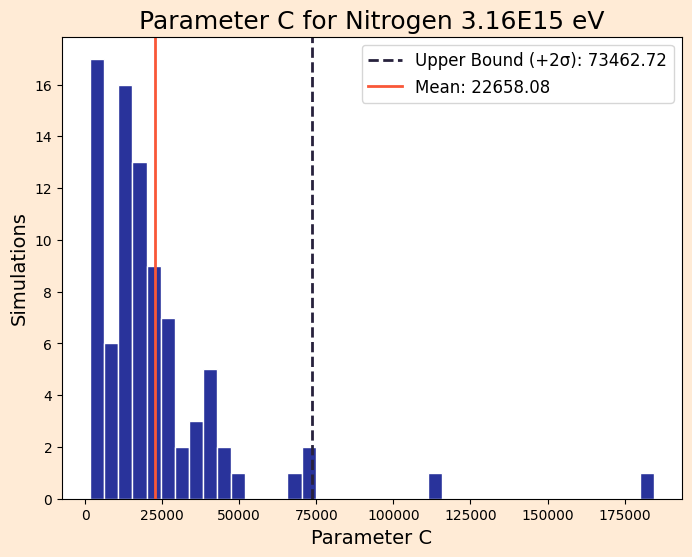

In [264]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['C'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('C')
plt.title('Parameter C for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['C'].mean()
std = parameters_df['C'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('Parameter C', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/par_c_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

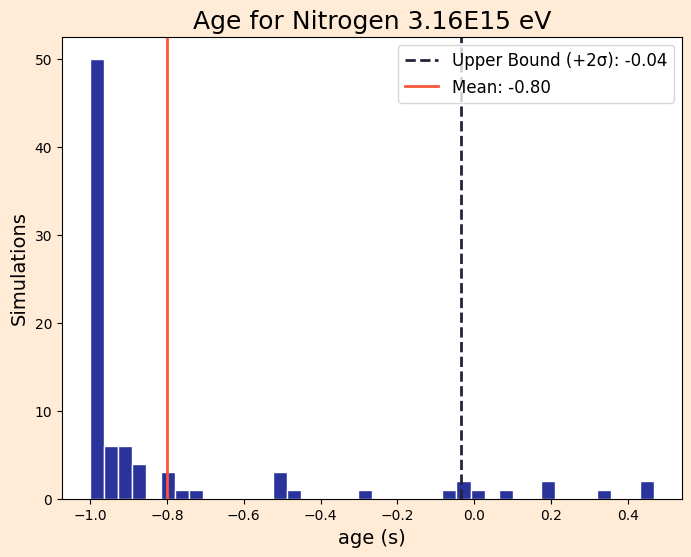

In [265]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['s'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('s')
plt.title('Age for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = parameters_df['s'].mean()
std = parameters_df['s'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('age (s)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/age_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

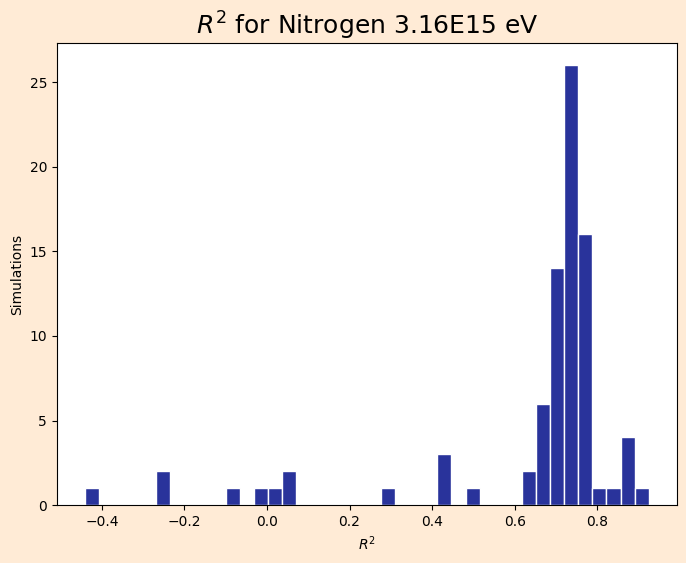

In [266]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['R_2'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('$R^2$')
plt.title('$R^2$ for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/rsquared_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

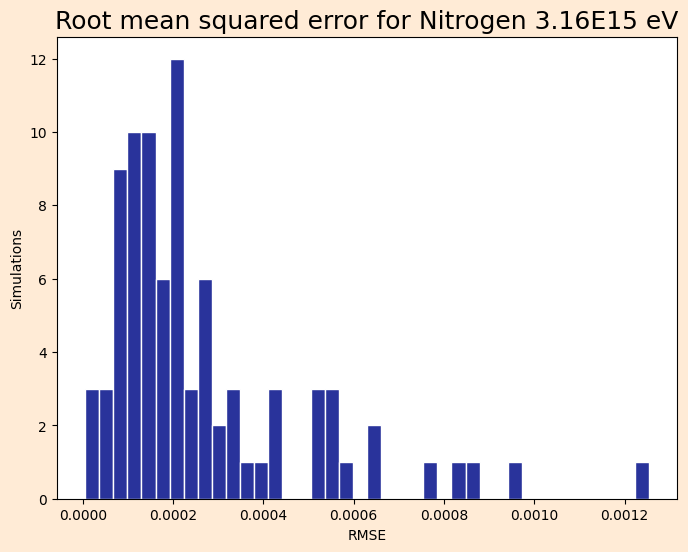

In [267]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(parameters_df['RMSE'], color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('RMSE')
plt.title('Root mean squared error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/rmse_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

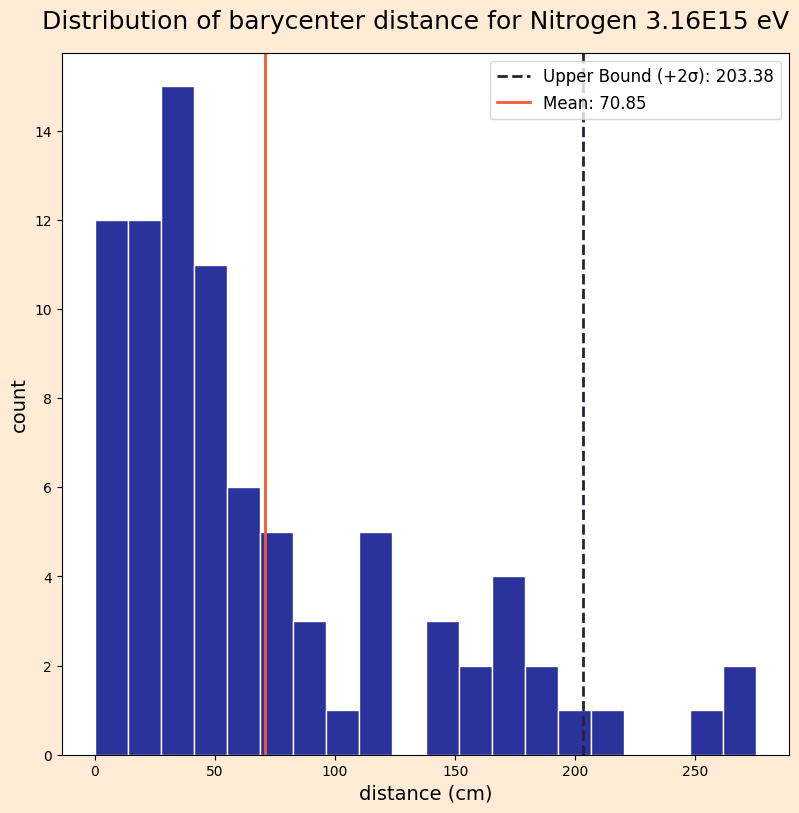

In [268]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Distribution of barycenter distance for ' + str(name) + ' eV', size = 18)
fig.tight_layout()

# Calcula a média e o desvio padrão dos dados
mean = df['r_b'].mean()
std = df['r_b'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

plt.hist(df['r_b'], color = '#29339B', edgecolor = 'white', bins = 20)

# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}')

# Personaliza o eixo e a legenda
ax.set_xlabel('distance (cm)', size=14)
ax.set_ylabel('count', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() + '/barycenter_' + caminho_arquivo.split('/')[-1] + '.png', bbox_inches = 'tight')

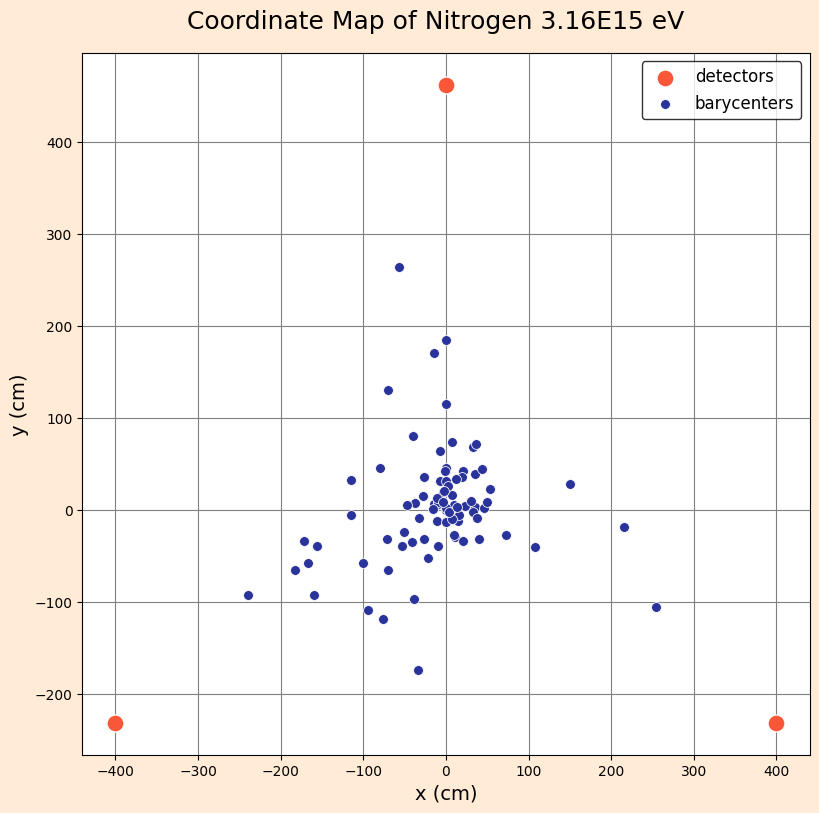

In [269]:
fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
fig.suptitle('Coordinate Map of ' + str(name) + ' eV', size = 18)
fig.tight_layout()
ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-')
ax.xaxis.grid(color='gray', linestyle='-')

sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
sns.scatterplot(x = df['x_b'], y = df['y_b'], ax = ax, color = '#29339B',s = 50)

ax.set_xlabel('x (cm)', size = 14)
ax.set_ylabel('y (cm)', size = 14)


ax.legend(['detectors', 'barycenters'], edgecolor = 'black', fontsize = 12, loc = 1)

plt.savefig('plots/' + name.split(' ')[0].lower() +'/map_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

In [270]:
# Plot dos tanques
#fig, ax = plt.subplots(1, 1, figsize = (8, 8), facecolor = '#FFEBD6')
#fig.suptitle('Coordinate Map of Detectors', size = 18)
#fig.tight_layout()
#ax.set_axisbelow(True)
#ax.yaxis.grid(color='gray', linestyle='-')
#ax.xaxis.grid(color='gray', linestyle='-')
#
#sns.scatterplot(x = [x1[0],x2[0],x3[0]], y = [x1[1],x2[1],x3[1]], ax = ax, color = '#F95738', s = 150)
#
#ax.set_xlabel('x (cm)', size = 14)
#ax.set_ylabel('y (cm)', size = 14)
#
#
#ax.legend(['detectors'], edgecolor = 'black', fontsize = 12, loc = 1)

[7.72879490e-18 5.80966465e-03]
[2.66092648 3.34151029 4.02294651 4.70353032]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11604\762320414.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_11604\762320414.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.665112,14.0,14.003073,0.021949
3.33385,14.499687,14.494063,0.038788
4.025715,15.0,15.002033,0.013553
4.704236,15.499687,15.500205,0.003344


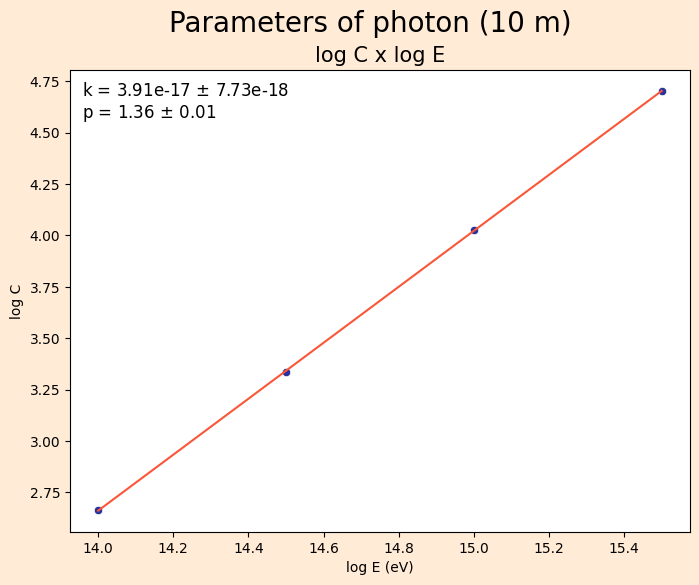

In [271]:
# Fit do fóton
from scipy.optimize import curve_fit

C = [462.5, 2157, 1.061e+04, 5.061e+04]
E = [1E14, 3.16E14, 1E15, 3.16E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_photon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_photon))

ax.plot(logE, power(E,*coefficients_photon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_photon[0],inc[0],coefficients_photon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_photon[0]))/coefficients_photon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df_photon = pl.DataFrame(data)

df_photon = df_photon.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df_photon

In [272]:
k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
c_photon = parameters_df['C'] 
#c_photon = df['C_optimized']
E_photon = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_photon)):
    E = (c_photon[i] / k_photon) ** (1 / p_photon)
    E_photon.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_photon,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
5.7489e14,81.807142,2.5851e15
1.8801e15,40.502006,1.2799e15
4.0628e15,28.570115,9.0282e14
1.0822e15,65.753882,2.0778e15
3.0639e15,3.042294,9.6136e13
…,…,…
1.8766e15,40.61425,1.2834e15
1.1468e15,63.708695,2.0132e15
2.0922e15,33.789949,1.0678e15


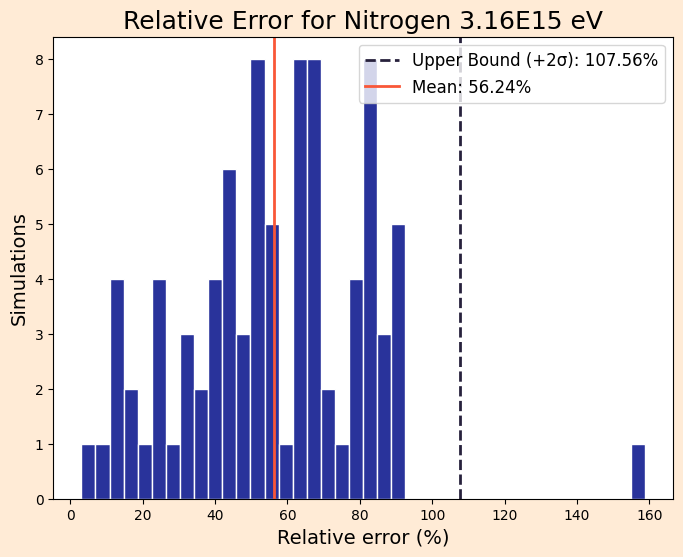

In [273]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

[1.29082114e-08 1.02286966e-01]
[2.93312376 3.33870508 3.74479438 4.1503757 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11604\2154559052.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_11604\2154559052.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.876507,14.0,13.930246,0.498243
3.464936,14.499687,14.655207,1.072578
3.662096,15.0,14.898114,0.67924
4.16346,15.499687,15.515807,0.104


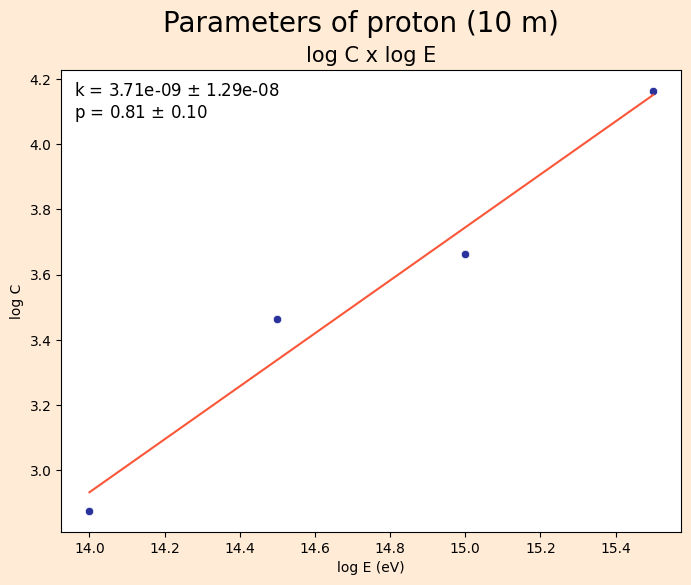

In [274]:
# Fit do próton
from scipy.optimize import curve_fit

C = [752.5, 2917, 4593, 1.457e+04]
E = [1E14, 3.16E14, 1E15, 3.16E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_proton, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_proton))

ax.plot(logE, power(E,*coefficients_proton), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_proton[0],inc[0],coefficients_proton[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_proton[0]))/coefficients_proton[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [275]:
k_proton = coefficients_proton[0] 
p_proton = coefficients_proton[1] 
c_proton = parameters_df['C'] 
#c_photon = df['C_optimized']
E_proton = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_proton)):
    E = (c_proton[i] / k_proton) ** (1 / p_proton)
    E_proton.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_proton,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
8.6950e14,72.484233,2.2905e15
6.3503e15,100.958343,3.1903e15
2.3138e16,632.222822,1.9978e16
2.5133e15,20.46503,6.4669e14
1.4410e16,356.022106,1.1250e16
…,…,…
6.3302e15,100.322584,3.1702e15
2.7702e15,12.334208,3.8976e14
7.5978e15,140.438266,4.4378e15


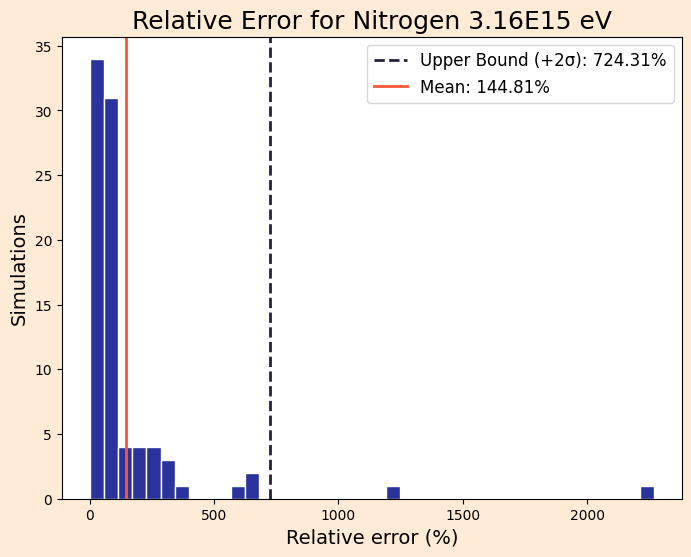

In [276]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

[3.49020900e-13 2.98935993e-01]
[2.55625971 3.12805531 3.70056706 4.27236266]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11604\2562053064.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_11604\2562053064.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.596377,14.0,14.035058,0.250416
3.265054,14.499687,14.619409,0.825685
3.305996,15.0,14.655188,2.298748
4.489818,15.499687,15.689719,1.226039


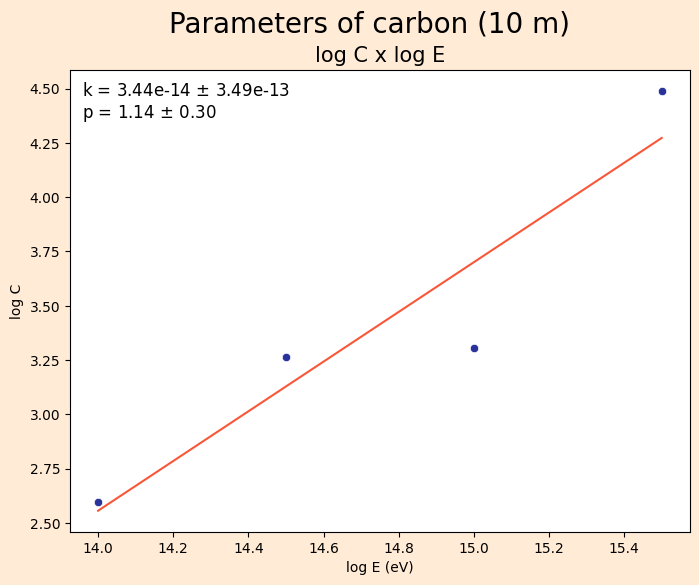

In [277]:
# Fit do carbono
from scipy.optimize import curve_fit

C = [394.8, 1841, 2023, 3.089e+04]
E = [1E14, 3.16E14, 1E15, 3.16E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of carbon (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_carbon, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_carbon))

ax.plot(logE, power(E,*coefficients_carbon), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_carbon[0],inc[0],coefficients_carbon[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_carbon[0]))/coefficients_carbon[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [278]:
k_carbon = coefficients_carbon[0] 
p_carbon = coefficients_carbon[1] 
c_carbon = parameters_df['C'] 
#c_photon = df['C_optimized']
E_carbon = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_carbon)):
    E = (c_carbon[i] / k_carbon) ** (1 / p_carbon)
    E_carbon.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_carbon,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
9.8986e14,68.675413,2.1701e15
4.0558e15,28.349257,8.9584e14
1.0148e16,221.142875,6.9881e15
2.1016e15,33.493913,1.0584e15
7.2529e15,129.521361,4.0929e15
…,…,…
4.0467e15,28.061108,8.8673e14
2.2518e15,28.74006,9.0819e14
4.6061e15,45.7629,1.4461e15


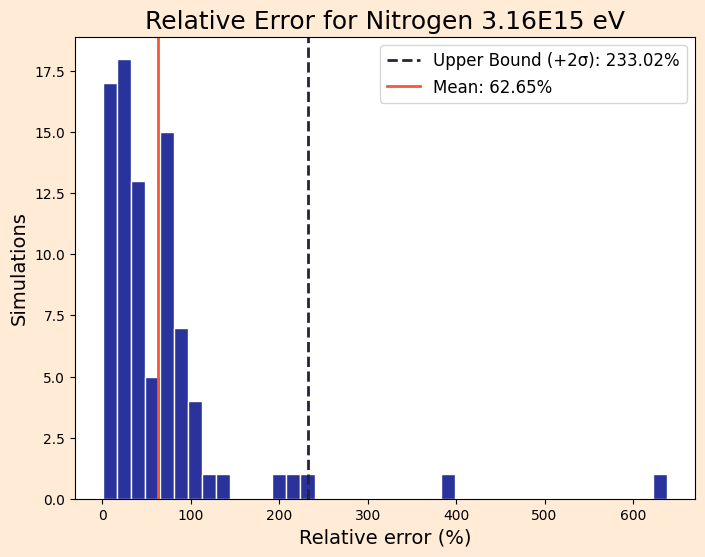

In [279]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

#plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

[2.13531837e-17 3.72073539e-02]
[2.45042069 3.13652323 3.82348508 4.50958763]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11604\2199846615.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_11604\2199846615.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.426674,14.0,13.982705,0.123534
3.184407,14.499687,14.534561,0.240516
3.798927,15.0,14.982114,0.119239
4.510009,15.499687,15.499994,0.001978


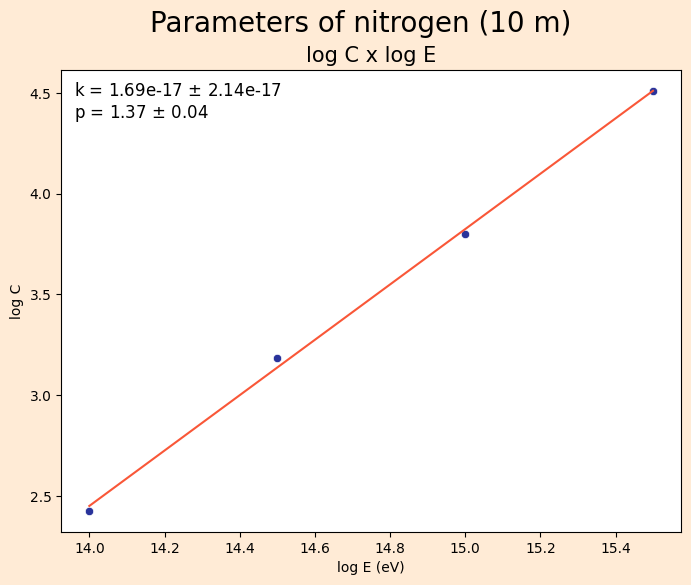

In [280]:
# Fit do nitrogênio
from scipy.optimize import curve_fit

C = [267.1, 1529, 6294, 3.236e+04]
E = [1E14, 3.16E14, 1E15, 3.16E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of nitrogen (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_nitrogen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_nitrogen))

ax.plot(logE, power(E,*coefficients_nitrogen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_nitrogen[0],inc[0],coefficients_nitrogen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_nitrogen[0]))/coefficients_nitrogen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [281]:
k_nitrogen = coefficients_nitrogen[0] 
p_nitrogen = coefficients_nitrogen[1] 
c_nitrogen = parameters_df['C'] 
#c_photon = df['C_optimized']
E_nitrogen = []
E_real = float(name.split(' ')[1])

erro_relativo = []
erro_absoluto = []

for i in range(len(c_nitrogen)):
    E = (c_nitrogen[i] / k_nitrogen) ** (1 / p_nitrogen)
    E_nitrogen.append(E)
    
    # Calcular erro absoluto
    erro_abs = abs(E - E_real)
    erro_absoluto.append(erro_abs)
    
    # Calcular erro relativo (em porcentagem)
    erro_rel = (erro_abs / E_real) * 100
    erro_relativo.append(erro_rel)

data = {
    'E':E_nitrogen,
    'Relative_error':erro_relativo,
    'Absolute_error':erro_absoluto
}

df3 = pl.DataFrame(data)
df3

E,Relative_error,Absolute_error
f64,f64,f64
8.0684e14,74.466988,2.3532e15
2.6137e15,17.288822,5.4633e14
5.6130e15,77.627509,2.4530e15
1.5111e15,52.180745,1.6489e15
4.2425e15,34.25743,1.0825e15
…,…,…
2.6088e15,17.443604,5.5122e14
1.6006e15,49.348604,1.5594e15
2.9060e15,8.037153,2.5397e14


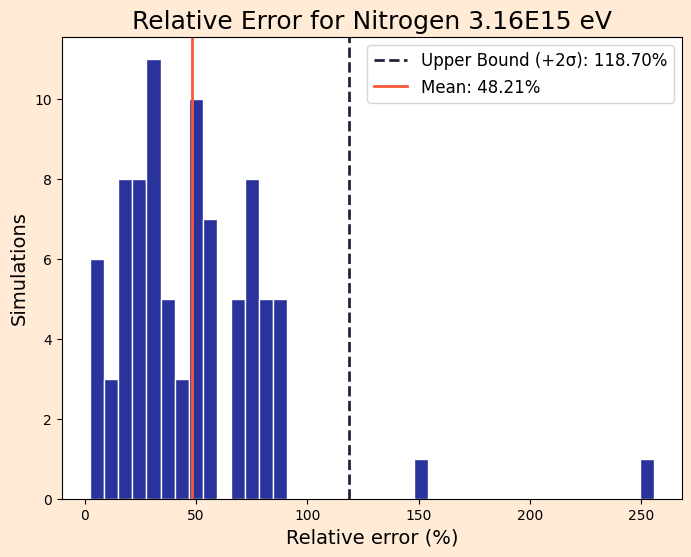

In [282]:
fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
plt.hist(erro_relativo, color='#29339B', bins= 40, edgecolor = 'white')
plt.ylabel('Simulations')
plt.xlabel('Relative Error (%)')
plt.title('Relative Error for ' + str(name) + ' eV', size = 18)
#plt.grid(True)

# Calcula a média e o desvio padrão dos dados
mean = df3['Relative_error'].mean()
std = df3['Relative_error'].std()

# Determina os limites de 2 sigma
#lower_bound = mean - 2 * std
upper_bound = mean + 2 * std


# Adiciona linhas verticais para os limites de 2 sigma
#ax.axvline(lower_bound, color='#548C2F', linestyle='--', linewidth=2, label=f'Lower Bound (-2σ): {lower_bound:.2f}')
ax.axvline(upper_bound, color='#27213C', linestyle='--', linewidth=2, label=f'Upper Bound (+2σ): {upper_bound:.2f}%')
ax.axvline(mean, color='#F95738', linestyle='-', linewidth=2, label=f'Mean: {mean:.2f}%')

# Personaliza o eixo e a legenda
ax.set_xlabel('Relative error (%)', size=14)
ax.set_ylabel('Simulations', size=14)
ax.legend(loc='upper right', fontsize=12)

plt.savefig('plots/' + name.split(' ')[0].lower() +'/energy_'+ caminho_arquivo.split('/')[-1] + '.png',bbox_inches = 'tight')

[3.30510011e-16 2.46194254e-02]
[3.7298276  4.41245988 5.09594713]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11604\3567477852.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_11604\3567477852.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.722716,14.0,13.994794,0.037183
4.426674,14.499687,14.510092,0.071758
5.088845,15.0,14.994801,0.034661


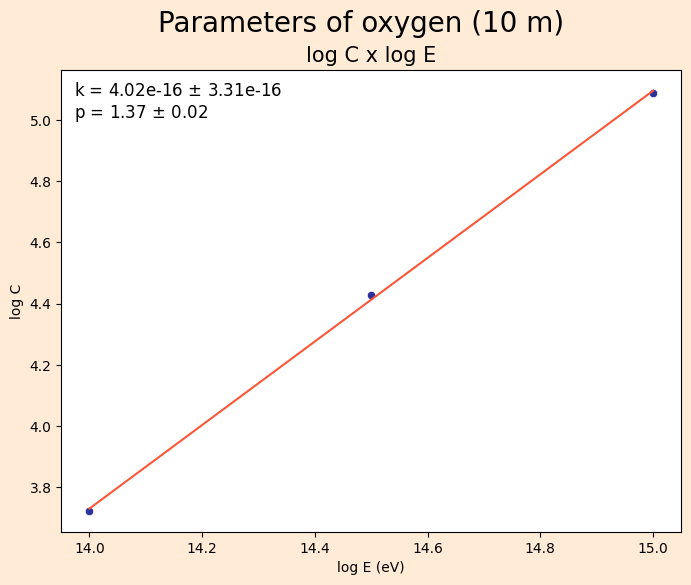

In [283]:
# Fit do oxigênio
from scipy.optimize import curve_fit

C = [5281, 2.671e+04, 1.227e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of oxygen (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_oxygen, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_oxygen))

ax.plot(logE, power(E,*coefficients_oxygen), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_oxygen[0],inc[0],coefficients_oxygen[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_oxygen[0]))/coefficients_oxygen[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[2.35395954e-15 3.98679384e-02]
[4.06730312 4.73902106 5.4115803 ]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_11604\3654635265.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
C:\Users\Lucas\AppData\Local\Temp\ipykernel_11604\3654635265.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
4.078819,14.0,14.008567,0.061191
4.716003,14.499687,14.482564,0.11809
5.423082,15.0,15.008556,0.05704


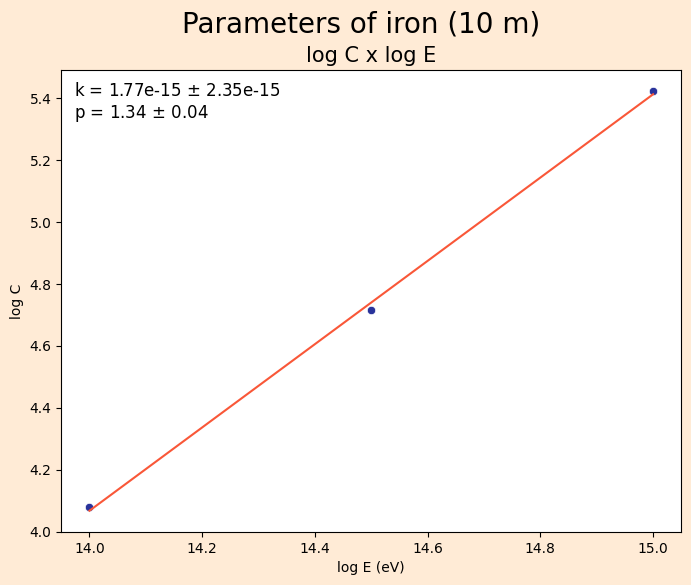

In [284]:
# Fit do ferro
from scipy.optimize import curve_fit

C = [1.199e+04, 5.2e+04, 2.649e+05]
E = [1E14, 3.16E14, 1E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron (10 m)', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients_iron, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients_iron))

ax.plot(logE, power(E,*coefficients_iron), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#29339B', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients_iron[0],inc[0],coefficients_iron[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients_iron[0]))/coefficients_iron[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

In [285]:
# Reconstrução da energia

E_real = [1E14, 3.16E14, 1E15]
r0 = 7800

# Parâmetros fóton

k_photon = coefficients_photon[0] 
p_photon = coefficients_photon[1] 
c_photon = [476.7,2411,1.293e+04] 
E_photon = []


for i in range(len(c_photon)):
    E = (c_photon[i]/k_photon)**(1/p_photon)
    E_photon.append(E)


# Parâmetros próton

k_proton = coefficients_proton[0]
p_proton = coefficients_proton[1]
c_proton = [566.7,2740,1.248e+04]
E_proton = []

for i in range(len(c_photon)):
    E = (c_proton[i]/k_proton)**(1/p_proton)
    E_proton.append(E)

# Parâmetros carbono

k_carbon = coefficients_carbon[0]
p_carbon = coefficients_carbon[1]
c_carbon = [158.1,861,6107]
E_carbon = []

for i in range(len(c_photon)):
    E = (c_carbon[i]/k_carbon)**(1/p_carbon)
    E_carbon.append(E)

# Parâmetros nitrogênio

k_nitrogen = coefficients_nitrogen[0]
p_nitrogen = coefficients_nitrogen[1]
c_nitrogen = [130.5,939.6,4829]
E_nitrogen = []

for i in range(len(c_photon)):
    E = (c_nitrogen[i]/k_nitrogen)**(1/p_nitrogen)
    E_nitrogen.append(E)

# Parâmetros oxigênio

k_oxygen = coefficients_oxygen[0]
p_oxygen = coefficients_oxygen[1]
c_oxygen = [132.3,775.1,5115]
E_oxygen = []

for i in range(len(c_photon)):
    E = (c_oxygen[i]/k_oxygen)**(1/p_oxygen)
    E_oxygen.append(E)

# Parâmetros ferro

k_iron = coefficients_iron[0]
p_iron = coefficients_iron[1]
c_iron = [36.59,294.4,2545]
E_iron = []

for i in range(len(c_iron)):
    E = (c_iron[i]/k_iron)**(1/p_iron)
    E_iron.append(E)
    


data = {
    'E':E_real,
    'E_photon':E_photon,
    'E_proton':E_proton,
    'E_carbon':E_carbon,
    'E_nitrogen':E_nitrogen,
    'E_oxygen':E_oxygen,
    'E_iron':E_iron
}

df = pl.DataFrame(data)
df

E,E_photon,E_proton,E_carbon,E_nitrogen,E_oxygen,E_iron
f64,f64,f64,f64,f64,f64,f64
1.0000e14,1.0297e14,6.0051e13,4.8723e13,5.7037e13,6.6489e12,1.3719e12
3.1600e14,3.3850e14,4.1852e14,2.1428e14,2.4019e14,2.4254e13,6.4712e12
1.0000e15,1.1617e15,2.7099e15,1.1872e15,7.9124e14,9.6525e13,3.2198e13


[Text(0.5, 1.0, 'Energy relative diviation $\\Delta$E/E')]

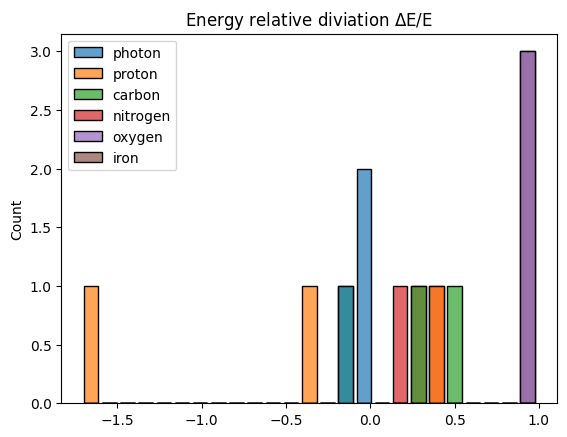

In [286]:
DeltaE_photon = []
DeltaE_proton = []
DeltaE_carbon = []
DeltaE_nitrogen = []
DeltaE_oxygen = []
DeltaE_iron = []

for i in range(len(E_real)):
    aux = (E_real[i] - E_photon[i])/E_real[i]
    aux2 = (E_real[i] - E_proton[i])/E_real[i]
    aux3 = (E_real[i] - E_carbon[i])/E_real[i]
    aux4 = (E_real[i] - E_nitrogen[i])/E_real[i]
    aux5 = (E_real[i] - E_oxygen[i])/E_real[i]
    aux6 = (E_real[i] - E_iron[i])/E_real[i]
    DeltaE_photon.append(aux)
    DeltaE_proton.append(aux2)
    DeltaE_carbon.append(aux3)
    DeltaE_nitrogen.append(aux4)
    DeltaE_oxygen.append(aux5)
    DeltaE_iron.append(aux6)

data = {
    'photon':DeltaE_photon,
    'proton':DeltaE_proton,
    'carbon':DeltaE_carbon,
    'nitrogen':DeltaE_nitrogen,
    'oxygen':DeltaE_oxygen,
    'iron':DeltaE_iron
}

sns.histplot(data=data, bins= 25, shrink=0.8, alpha = 0.7).set(title = 'Energy relative diviation $\Delta$E/E')



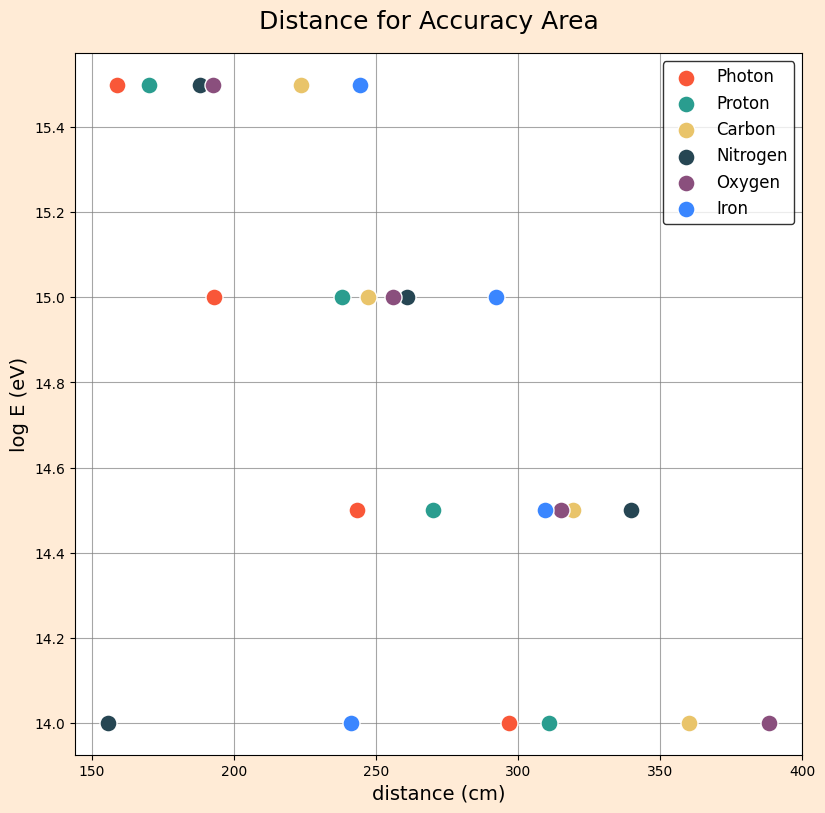

In [287]:
energy1 = [1E14, 3.16E14, 1E15, 3.16E15]
energy = np.log10(energy1)

photon = [296.76, 243.37, 192.98, 158.92]
proton = [310.83, 269.99, 238.02, 169.90]
carbon = [360.12, 319.32, 246.98, 223.55]
nitrogen = [155.69, 339.63, 260.88, 187.82]
oxygen = [388.38, 315.07, 256.06, 192.68]
iron = [241.06, 309.35, 292.14, 244.16]

fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Distance for Accuracy Area', size=18)
fig.tight_layout()

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-', alpha=0.7)
ax.xaxis.grid(color='gray', linestyle='-', alpha=0.7)

sns.scatterplot(x=photon, y=energy, ax=ax, color='#F95738', s=150, label='Photon')
sns.scatterplot(x=proton, y=energy, ax=ax, color='#2A9D8F', s=150, label='Proton')
sns.scatterplot(x=carbon, y=energy, ax=ax, color='#E9C46A', s=150, label='Carbon')
sns.scatterplot(x=nitrogen, y=energy, ax=ax, color='#264653', s=150, label='Nitrogen')
sns.scatterplot(x=oxygen, y=energy, ax=ax, color='#8A4F7D', s=150, label='Oxygen')
sns.scatterplot(x=iron, y=energy, ax=ax, color='#3A86FF', s=150, label='Iron')

ax.set_xlabel('distance (cm)', size=14)
ax.set_ylabel('log E (eV)', size=14)

ax.legend(edgecolor='black', fontsize=12, loc='upper right')

plt.show()


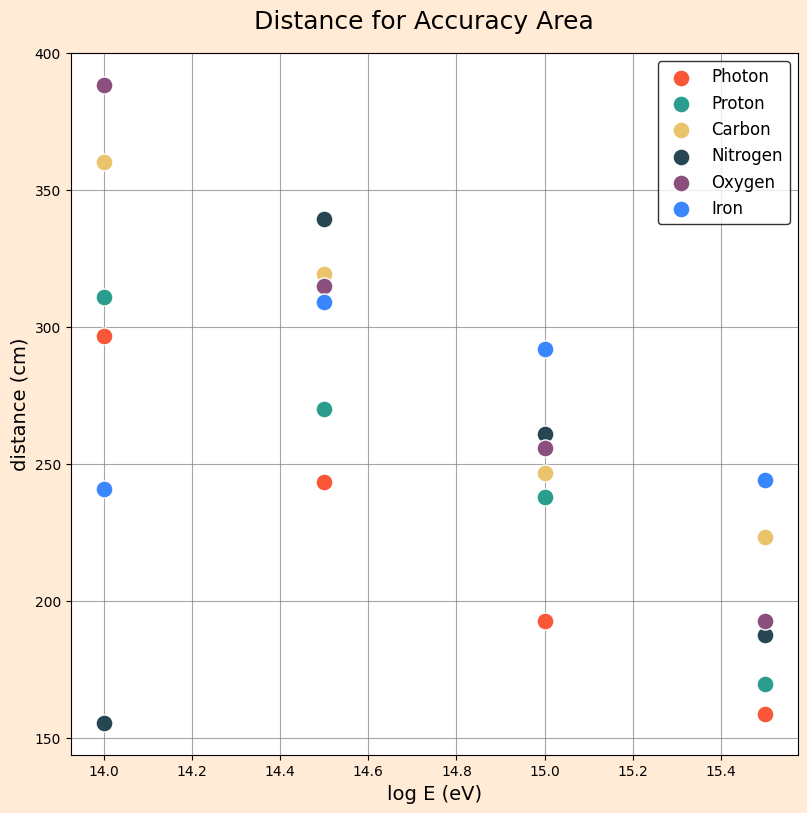

In [288]:
energy1 = [1E14, 3.16E14, 1E15, 3.16E15]
energy = np.log10(energy1)

photon = [296.76, 243.37, 192.98, 158.92]
proton = [310.83, 269.99, 238.02, 169.90]
carbon = [360.12, 319.32, 246.98, 223.55]
nitrogen = [155.69, 339.63, 260.88, 187.82]
oxygen = [388.38, 315.07, 256.06, 192.68]
iron = [241.06, 309.35, 292.14, 244.16]

fig, ax = plt.subplots(1, 1, figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Distance for Accuracy Area', size=18)
fig.tight_layout()

ax.set_axisbelow(True)
ax.yaxis.grid(color='gray', linestyle='-', alpha=0.7)
ax.xaxis.grid(color='gray', linestyle='-', alpha=0.7)

sns.scatterplot(y=photon, x=energy, ax=ax, color='#F95738', s=150, label='Photon')
sns.scatterplot(y=proton, x=energy, ax=ax, color='#2A9D8F', s=150, label='Proton')
sns.scatterplot(y=carbon, x=energy, ax=ax, color='#E9C46A', s=150, label='Carbon')
sns.scatterplot(y=nitrogen, x=energy, ax=ax, color='#264653', s=150, label='Nitrogen')
sns.scatterplot(y=oxygen, x=energy, ax=ax, color='#8A4F7D', s=150, label='Oxygen')
sns.scatterplot(y=iron, x=energy, ax=ax, color='#3A86FF', s=150, label='Iron')

ax.set_xlabel('log E (eV)', size=14)
ax.set_ylabel('distance (cm)', size=14)

ax.legend(edgecolor='black', fontsize=12, loc='upper right')

plt.show()


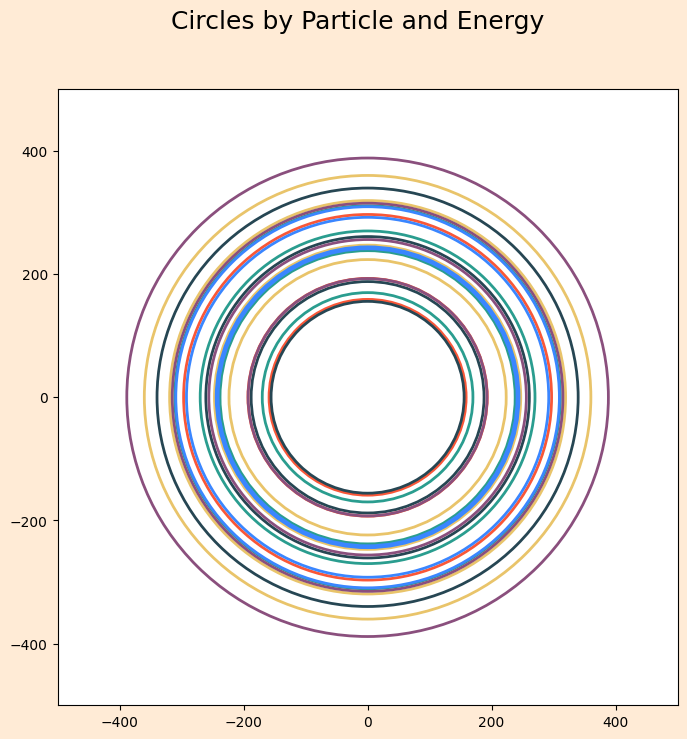

In [289]:
fig, ax = plt.subplots(1,1,figsize=(8, 8), facecolor='#FFEBD6')
fig.suptitle('Circles by Particle and Energy', size=18)

for i, e in enumerate(energy):  
    radius = photon[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#F95738', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = proton[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#2A9D8F', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = carbon[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#E9C46A', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = nitrogen[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#264653', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

for i, e in enumerate(energy):  
    radius = oxygen[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#8A4F7D', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)


for i, e in enumerate(energy):  
    radius = iron[i]  
    circle = plt.Circle((0, 0), radius=radius, color='#3A86FF', fill = False, linewidth = 2, label=f'{e:.2E} eV' if i == 0 else None)
    ax.add_patch(circle)

plt.xlim([-500,500])
plt.ylim([-500,500])

plt.show()